# Overlay experimental BCC force constants on the GA-discovered solution landscape

This notebook loads:

1. `dataframe000013.pkl`
2. `dataframe000014.pkl`
3. `bcc_experimental_force_constants_alpha_beta.csv`

It selects the **top 5 overall** GA solutions for each independent dataset and each `(mass, lattice parameter)` pair, performs PCA on the GA force-constant space,

\[
(\alpha_1,\beta_1,\alpha_2,\beta_2),
\]

and then projects the experimental Cr, V, and Fe force constants into the **same standardized PCA space**.

The goal is to test where experimentally fitted BCC transition-metal force constants fall relative to the GA-discovered force-constant families.

The notebook produces publication-quality figures suitable for manuscript use.


In [4]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

%config InlineBackend.figure_format = "retina"

# -----------------------------------------------------------------------------
# User settings
# -----------------------------------------------------------------------------

# Update this path if your pickle files are somewhere else.
PKL_DIR = Path("./dataframes/")  # e.g., Path("/Users/jamunoz/Documents/GitHub/MOGA-Phonons/dataframes")

DATAFRAME_FILES = {
    "dataframe000013": PKL_DIR / "dataframe000013.pkl",
    "dataframe000014": PKL_DIR / "dataframe000014.pkl",
    "dataframe000015": PKL_DIR / "dataframe000015.pkl",
    "dataframe000016": PKL_DIR / "dataframe000016.pkl",
}

# Put this CSV file in the same directory as this notebook, or update the path.
EXPERIMENTAL_CSV = Path("bcc_experimental_force_constants_alpha_beta.csv")

OUTPUT_DIR = Path("experimental_overlay_force_constant_space")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TOP_K = 5
RANK_BY = "fitness_norm"

SAVE_FORMATS = ("pdf", "png")
DPI = 300

FIGSIZE = (6.8, 5.6)
MARKER_SIZE_GA = 56
MARKER_SIZE_EXP = 120
MARKER_ALPHA_GA = 0.72
EDGE_WIDTH = 0.35

ZERO_TOL = 0.08

# The experimental CSV uses four force constants.
# To compare directly, the GA projection is also built in this 4D subspace.
EXPERIMENTAL_FORCE_CONSTANTS = [
    "alpha1_eV_A2",
    "beta1_eV_A2",
    "alpha2_eV_A2",
    "beta2_eV_A2",
]


In [5]:
def find_first_existing(candidates, columns):
    for col in candidates:
        if col in columns:
            return col
    return None


def load_dataframe(path, dataset_label):
    if not path.exists():
        raise FileNotFoundError(
            f"Could not find {path}. Update PKL_DIR or DATAFRAME_FILES."
        )
    df = pd.read_pickle(path).copy()
    df["dataset"] = dataset_label
    return df


def display_label(col):
    label_map = {
        "mass": r"$m$ (amu)", "m": r"$m$ (amu)",
        "a_val": r"$a$ ($\AA$)", "alat": r"$a$ ($\AA$)",
        "a_latt": r"$a$ ($\AA$)", "lattice_parameter": r"$a$ ($\AA$)",
        "alpha0": r"$\alpha_0$",
        "alpha_0": r"$\alpha_0$",
        "alpha1": r"$\alpha_1$",
        "alpha_1": r"$\alpha_1$",
        "beta1": r"$\beta_1$",
        "beta_1": r"$\beta_1$",
        "alpha2": r"$\alpha_2$",
        "alpha_2": r"$\alpha_2$",
        "beta2": r"$\beta_2$",
        "beta_2": r"$\beta_2$",
        "fitness_norm": r"$f_{\mathrm{norm}}$",
        "fnorm": r"$f_{\mathrm{norm}}$",
        "r_alpha2": r"$r_{\alpha_2}$",
        "temperature_K": r"$T$ (K)",
        "alpha1_eV_A2": r"$\alpha_1$",
        "beta1_eV_A2": r"$\beta_1$",
        "alpha2_eV_A2": r"$\alpha_2$",
        "beta2_eV_A2": r"$\beta_2$",
    }
    return label_map.get(col, col)


def apply_publication_axes(ax):
    ax.tick_params(
        axis="both",
        which="both",
        direction="in",
        top=True,
        right=True,
        labelsize=12,
        length=5,
        width=1.1,
    )
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.1)


def save_figure(fig, stem, output_dir=OUTPUT_DIR, formats=SAVE_FORMATS):
    output_dir.mkdir(parents=True, exist_ok=True)
    saved = []
    for ext in formats:
        outpath = output_dir / f"{stem}.{ext}"
        fig.savefig(outpath, dpi=DPI, bbox_inches="tight")
        saved.append(outpath)
    print("Saved:")
    for path in saved:
        print(f"  {path}")
    return saved


def classify_family_from_alpha2_beta2(alpha2, beta2, zero_tol=ZERO_TOL):
    if abs(beta2) <= zero_tol and abs(alpha2) > zero_tol:
        return r"$\alpha_2$-dominated"
    if abs(alpha2) <= zero_tol and abs(beta2) > zero_tol:
        return r"$\beta_2$-dominated"
    if abs(alpha2) > abs(beta2):
        return r"$\alpha_2$ larger"
    if abs(beta2) > abs(alpha2):
        return r"$\beta_2$ larger"
    return "balanced"


def add_element_labels(ax, data, x_col="PC1", y_col="PC2"):
    """Add labels for Cr, V, and selected Fe points."""
    for _, row in data.iterrows():
        element = row["element"]
        T = row["temperature_K"]

        # Label all non-Fe points and selected Fe endpoints/room-temperature points.
        label = None
        if element != "Fe":
            label = element
        elif T in [30, 300, 1180]:
            label = f"Fe {int(T)} K"

        if label is not None:
            ax.annotate(
                label,
                xy=(row[x_col], row[y_col]),
                xytext=(6, 6),
                textcoords="offset points",
                fontsize=10,
                ha="left",
                va="bottom",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="0.7", alpha=0.85),
            )


In [6]:
# -----------------------------------------------------------------------------
# Load GA dataframes
# -----------------------------------------------------------------------------

frames = []
for label, path in DATAFRAME_FILES.items():
    tmp = load_dataframe(path, label)
    print(f"{label}: {tmp.shape[0]:,} rows, {tmp.shape[1]:,} columns")
    frames.append(tmp)

df_all = pd.concat(frames, ignore_index=True)
print(f"\nAggregated GA dataframe before filtering: {df_all.shape[0]:,} rows")
df_all.head()


dataframe000013: 105,000 rows, 35 columns
dataframe000014: 105,000 rows, 35 columns
dataframe000015: 105,000 rows, 35 columns
dataframe000016: 105,000 rows, 35 columns

Aggregated GA dataframe before filtering: 420,000 rows


,simulation,generation,solution_index,rank,source,timestamp,mass,a_val,system_size,alpha0,...,gamma_frequencies,distances,qpoints,frequencies,frequency_vector,simulation_path,generation_dir,solution_dir,band_yaml_path,dataset
0,simulation000588,1,5,0,population,2026-05-22T19:33:42.238245,50.0,2.0,5,5.607430,...,"[0.8275024, 0.8275024, 0.8275024]","[0.0, 0.0025, 0.005, 0.0075, 0.01, 0.0125, 0.0...","[[0.0, 0.0, 0.0], [-0.0025, 0.0025, 0.0025], [...","[[0.8275024, 0.8275024, 0.8275024], [0.8291954...","[0.8275024, 0.8275024, 0.8275024, 0.8291954, 0...",simulations/simulation000588,simulations/simulation000588/phonon_generation...,simulations/simulation000588/phonon_generation...,simulations/simulation000588/phonon_generation...,dataframe000013
1,simulation000588,1,92,1,population,2026-05-22T19:33:42.238245,50.0,2.0,5,6.189523,...,"[1.562392, 1.562392, 1.562392]","[0.0, 0.0025, 0.005, 0.0075, 0.01, 0.0125, 0.0...","[[0.0, 0.0, 0.0], [-0.0025, 0.0025, 0.0025], [...","[[1.562392, 1.562392, 1.562392], [1.563087, 1....","[1.562392, 1.562392, 1.562392, 1.563087, 1.563...",simulations/simulation000588,simulations/simulation000588/phonon_generation...,simulations/simulation000588/phonon_generation...,simulations/simulation000588/phonon_generation...,dataframe000013
2,simulation000588,1,44,2,population,2026-05-22T19:33:42.238245,50.0,2.0,5,3.931578,...,"[-1.0034583, -1.0034583, -1.0034583]","[0.0, 0.0025, 0.005, 0.0075, 0.01, 0.0125, 0.0...","[[0.0, 0.0, 0.0], [-0.0025, 0.0025, 0.0025], [...","[[-1.0034583, -1.0034583, -1.0034583], [-1.002...","[-1.0034583, -1.0034583, -1.0034583, -1.002285...",simulations/simulation000588,simulations/simulation000588/phonon_generation...,simulations/simulation000588/phonon_generation...,simulations/simulation000588/phonon_generation...,dataframe000013
3,simulation000588,1,155,3,population,2026-05-22T19:33:42.238245,50.0,2.0,5,6.349680,...,"[1.0862614, 1.0862614, 1.0862614]","[0.0, 0.0025, 0.005, 0.0075, 0.01, 0.0125, 0.0...","[[0.0, 0.0, 0.0], [-0.0025, 0.0025, 0.0025], [...","[[1.0862614, 1.0862614, 1.0862614], [1.0880687...","[1.0862614, 1.0862614, 1.0862614, 1.0880687, 1...",simulations/simulation000588,simulations/simulation000588/phonon_generation...,simulations/simulation000588/phonon_generation...,simulations/simulation000588/phonon_generation...,dataframe000013
4,simulation000588,1,125,4,population,2026-05-22T19:33:42.238245,50.0,2.0,5,8.587408,...,"[-1.2866693, -1.2866693, -1.2866693]","[0.0, 0.0025, 0.005, 0.0075, 0.01, 0.0125, 0.0...","[[0.0, 0.0, 0.0], [-0.0025, 0.0025, 0.0025], [...","[[-1.2866693, -1.2866693, -1.2866693], [-1.284...","[-1.2866693, -1.2866693, -1.2866693, -1.284834...",simulations/simulation000588,simulations/simulation000588/phonon_generation...,simulations/simulation000588/phonon_generation...,simulations/simulation000588/phonon_generation...,dataframe000013


In [7]:
# -----------------------------------------------------------------------------
# Detect GA columns and select top 5 overall solutions
# -----------------------------------------------------------------------------

mass_col = find_first_existing(["mass", "m"], df_all.columns)
alat_col = find_first_existing(["a_val", "alat", "a_latt", "lattice_parameter"], df_all.columns)
rank_col = find_first_existing([RANK_BY, "fitness_norm", "fnorm"], df_all.columns)

alpha1_col = find_first_existing(["alpha1", "alpha_1"], df_all.columns)
beta1_col  = find_first_existing(["beta1", "beta_1"], df_all.columns)
alpha2_col = find_first_existing(["alpha2", "alpha_2"], df_all.columns)
beta2_col  = find_first_existing(["beta2", "beta_2"], df_all.columns)

ga_force_constant_cols = [alpha1_col, beta1_col, alpha2_col, beta2_col]

required = {
    "mass": mass_col,
    "lattice parameter": alat_col,
    "ranking": rank_col,
    "alpha1": alpha1_col,
    "beta1": beta1_col,
    "alpha2": alpha2_col,
    "beta2": beta2_col,
}

for name, col in required.items():
    if col is None:
        raise ValueError(f"Could not find required GA column for {name}.")

print("Detected GA columns:")
for name, col in required.items():
    print(f"{name:20s}: {col}")

df_ga = (
    df_all.sort_values(rank_col, ascending=False)
    .groupby(["dataset", mass_col, alat_col], group_keys=False)
    .head(TOP_K)
    .copy()
)

for col in [mass_col, alat_col, rank_col] + ga_force_constant_cols:
    df_ga[col] = pd.to_numeric(df_ga[col], errors="coerce")

df_ga = df_ga.dropna(subset=[mass_col, alat_col, rank_col] + ga_force_constant_cols).copy()

df_ga["source"] = "GA"
df_ga["r_alpha2"] = (
    df_ga[alpha2_col].abs()
    / (df_ga[alpha2_col].abs() + df_ga[beta2_col].abs() + 1e-12)
)
df_ga["family"] = [
    classify_family_from_alpha2_beta2(a2, b2)
    for a2, b2 in zip(df_ga[alpha2_col], df_ga[beta2_col])
]

print(f"\nGA rows after top-{TOP_K}-overall selection: {df_ga.shape[0]:,}")
print(df_ga["family"].value_counts())
df_ga[["dataset", mass_col, alat_col, rank_col] + ga_force_constant_cols + ["r_alpha2", "family"]].head()


Detected GA columns:
mass                : mass
lattice parameter   : a_val
ranking             : fitness_norm
alpha1              : alpha1
beta1               : beta1
alpha2              : alpha2
beta2               : beta2

GA rows after top-5-overall selection: 840
family
$\beta_2$-dominated     600
$\alpha_2$-dominated    205
$\beta_2$ larger         20
$\alpha_2$ larger        15
Name: count, dtype: int64


,dataset,mass,a_val,fitness_norm,alpha1,beta1,alpha2,beta2,r_alpha2,family
214621,dataframe000015,50.0,2.2,1.731862,-0.321338,-0.017194,0.000162,-0.650614,0.000249,$\beta_2$-dominated
214938,dataframe000015,50.0,2.2,1.731862,-0.321338,0.025992,0.000162,-0.650614,0.000249,$\beta_2$-dominated
214926,dataframe000015,50.0,2.2,1.731862,-0.321338,0.025992,0.000162,-0.650614,0.000249,$\beta_2$-dominated
214927,dataframe000015,50.0,2.2,1.731862,-0.321338,0.631618,0.000162,-0.650614,0.000249,$\beta_2$-dominated
214928,dataframe000015,50.0,2.2,1.731862,-0.321338,0.025992,0.000162,-0.650614,0.000249,$\beta_2$-dominated


In [8]:
# -----------------------------------------------------------------------------
# Load experimental force constants
# -----------------------------------------------------------------------------

if not EXPERIMENTAL_CSV.exists():
    raise FileNotFoundError(
        f"Could not find {EXPERIMENTAL_CSV}. Put the CSV in the same directory "
        "as this notebook or update EXPERIMENTAL_CSV."
    )

df_exp = pd.read_csv(EXPERIMENTAL_CSV)

required_exp = ["element", "temperature_K"] + EXPERIMENTAL_FORCE_CONSTANTS
missing = [c for c in required_exp if c not in df_exp.columns]
if missing:
    raise ValueError(f"Experimental CSV is missing columns: {missing}")

for col in ["temperature_K"] + EXPERIMENTAL_FORCE_CONSTANTS:
    df_exp[col] = pd.to_numeric(df_exp[col], errors="coerce")

df_exp = df_exp.dropna(subset=required_exp).copy()

df_exp["source"] = "experiment"
df_exp["r_alpha2"] = (
    df_exp["alpha2_eV_A2"].abs()
    / (df_exp["alpha2_eV_A2"].abs() + df_exp["beta2_eV_A2"].abs() + 1e-12)
)
df_exp["family"] = [
    classify_family_from_alpha2_beta2(a2, b2)
    for a2, b2 in zip(df_exp["alpha2_eV_A2"], df_exp["beta2_eV_A2"])
]

print(f"Experimental rows: {df_exp.shape[0]:,}")
print(df_exp.groupby("element").size())
df_exp.head()


Experimental rows: 41
element
Cr     1
Fe    39
V      1
dtype: int64


,element,temperature_K,alpha1_eV_A2,beta1_eV_A2,alpha2_eV_A2,beta2_eV_A2,source,r_alpha2,family
0,Cr,300,-0.844,-0.405,-2.242,0.098,experiment,0.958120,$\alpha_2$ larger
1,V,300,-0.679,-0.452,-0.405,0.134,experiment,0.751391,$\alpha_2$ larger
2,Fe,300,-1.054,-0.937,-0.913,-0.034,experiment,0.964097,$\alpha_2$-dominated
3,Fe,30,-1.110,-0.972,-1.053,-0.026,experiment,0.975904,$\alpha_2$-dominated
4,Fe,50,-1.094,-0.977,-1.048,-0.019,experiment,0.982193,$\alpha_2$-dominated


## PCA projection

The PCA basis is fit **only to the GA top solutions**. The experimental force constants are then transformed using the same scaler and PCA model. This answers the question:

> Where do the experimental BCC force constants fall in the GA-discovered force-constant landscape?

Because the experimental CSV contains only \((\alpha_1,\beta_1,\alpha_2,\beta_2)\), the PCA is performed in this four-dimensional subspace.


In [9]:
# -----------------------------------------------------------------------------
# Fit PCA on GA top solutions and project experimental points
# -----------------------------------------------------------------------------

X_ga = df_ga[ga_force_constant_cols].to_numpy(dtype=float)

scaler = StandardScaler()
X_ga_scaled = scaler.fit_transform(X_ga)

pca = PCA(n_components=4)
scores_ga = pca.fit_transform(X_ga_scaled)

# Map experimental columns to the same order as the GA columns:
# alpha1, beta1, alpha2, beta2
X_exp = df_exp[EXPERIMENTAL_FORCE_CONSTANTS].to_numpy(dtype=float)
X_exp_scaled = scaler.transform(X_exp)
scores_exp = pca.transform(X_exp_scaled)

df_ga["PC1"] = scores_ga[:, 0]
df_ga["PC2"] = scores_ga[:, 1]

df_exp["PC1"] = scores_exp[:, 0]
df_exp["PC2"] = scores_exp[:, 1]

explained = pca.explained_variance_ratio_

print("PCA explained variance ratio:")
for i, val in enumerate(explained, start=1):
    print(f"PC{i}: {val:.4f}")

loadings = pd.DataFrame(
    pca.components_.T,
    index=[display_label(c) for c in ga_force_constant_cols],
    columns=[f"PC{i}" for i in range(1, 5)],
)

loadings


PCA explained variance ratio:
PC1: 0.4775
PC2: 0.2528
PC3: 0.2241
PC4: 0.0455


,PC1,PC2,PC3,PC4
$\alpha_1$,-0.502660,0.275918,0.667337,0.475251
$\beta_1$,0.050428,0.937730,-0.343577,-0.008642
$\alpha_2$,-0.521364,-0.209435,-0.660659,0.497843
$\beta_2$,0.687728,-0.025862,0.012107,0.725407


Saved:
  experimental_overlay_force_constant_space/pca_ga_landscape_with_experimental_overlay_by_family.pdf
  experimental_overlay_force_constant_space/pca_ga_landscape_with_experimental_overlay_by_family.png


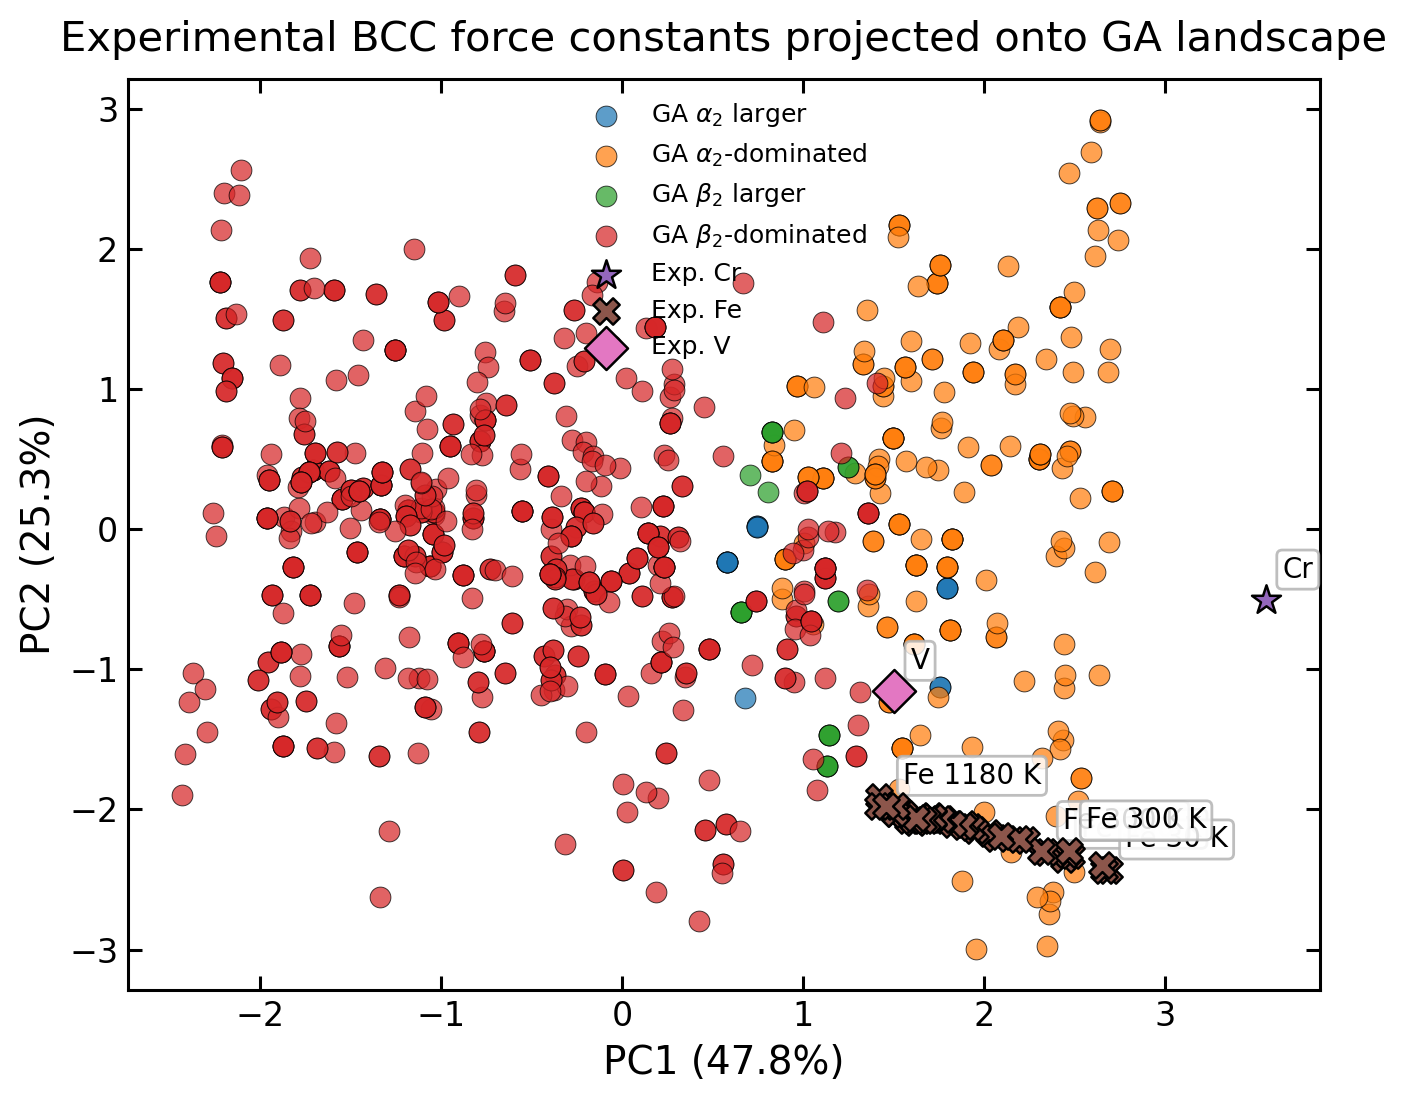

In [10]:
# -----------------------------------------------------------------------------
# Figure 1: GA landscape colored by family, experimental points overlaid
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=FIGSIZE)

# GA points by family.
for family, sub in df_ga.groupby("family"):
    ax.scatter(
        sub["PC1"],
        sub["PC2"],
        s=MARKER_SIZE_GA,
        alpha=MARKER_ALPHA_GA,
        edgecolors="black",
        linewidths=EDGE_WIDTH,
        label=f"GA {family}",
    )

# Experimental markers by element.
element_markers = {
    "Cr": "*",
    "V": "D",
    "Fe": "X",
}

for element, sub in df_exp.groupby("element"):
    ax.scatter(
        sub["PC1"],
        sub["PC2"],
        s=MARKER_SIZE_EXP if element != "Fe" else MARKER_SIZE_EXP * 0.75,
        marker=element_markers.get(element, "P"),
        edgecolors="black",
        linewidths=0.9,
        label=f"Exp. {element}",
        zorder=5,
    )

add_element_labels(ax, df_exp)

ax.set_xlabel(f"PC1 ({explained[0]*100:.1f}%)", fontsize=14)
ax.set_ylabel(f"PC2 ({explained[1]*100:.1f}%)", fontsize=14)
ax.set_title("Experimental BCC force constants projected onto GA landscape", fontsize=15, pad=10)

apply_publication_axes(ax)
ax.legend(frameon=False, fontsize=9, loc="best", ncol=1)

fig.tight_layout()
save_figure(fig, "pca_ga_landscape_with_experimental_overlay_by_family")
plt.show()


Saved:
  experimental_overlay_force_constant_space/pca_ga_landscape_with_experimental_overlay_colored_by_r_alpha2.pdf
  experimental_overlay_force_constant_space/pca_ga_landscape_with_experimental_overlay_colored_by_r_alpha2.png


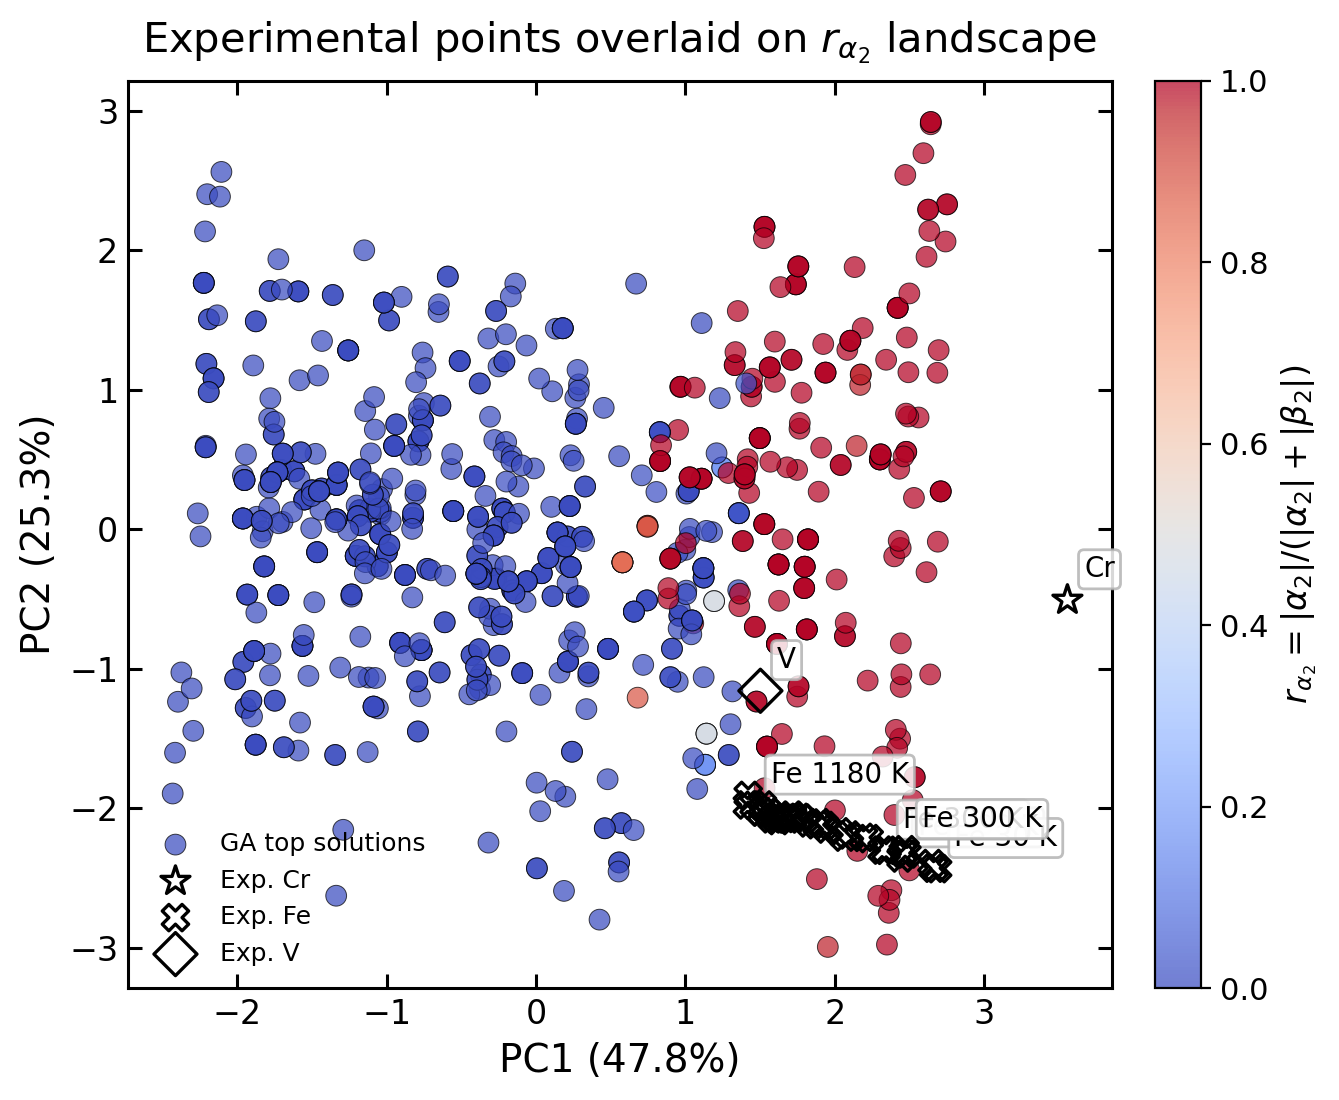

In [11]:
# -----------------------------------------------------------------------------
# Figure 2: GA landscape colored by r_alpha2, experimental points overlaid
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=FIGSIZE)

sc = ax.scatter(
    df_ga["PC1"],
    df_ga["PC2"],
    c=df_ga["r_alpha2"],
    cmap="coolwarm",
    vmin=0,
    vmax=1,
    s=MARKER_SIZE_GA,
    alpha=MARKER_ALPHA_GA,
    edgecolors="black",
    linewidths=EDGE_WIDTH,
    label="GA top solutions",
)

for element, sub in df_exp.groupby("element"):
    ax.scatter(
        sub["PC1"],
        sub["PC2"],
        s=MARKER_SIZE_EXP if element != "Fe" else MARKER_SIZE_EXP * 0.75,
        marker=element_markers.get(element, "P"),
        facecolors="none",
        edgecolors="black",
        linewidths=1.2,
        label=f"Exp. {element}",
        zorder=6,
    )

add_element_labels(ax, df_exp)

ax.set_xlabel(f"PC1 ({explained[0]*100:.1f}%)", fontsize=14)
ax.set_ylabel(f"PC2 ({explained[1]*100:.1f}%)", fontsize=14)
ax.set_title(r"Experimental points overlaid on $r_{\alpha_2}$ landscape", fontsize=15, pad=10)

apply_publication_axes(ax)

cbar = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label(r"$r_{\alpha_2}=|\alpha_2|/(|\alpha_2|+|\beta_2|)$", fontsize=12)
cbar.ax.tick_params(labelsize=11)

ax.legend(frameon=False, fontsize=9, loc="best")

fig.tight_layout()
save_figure(fig, "pca_ga_landscape_with_experimental_overlay_colored_by_r_alpha2")
plt.show()


Saved:
  experimental_overlay_force_constant_space/alpha2_beta2_ga_with_experimental_overlay.pdf
  experimental_overlay_force_constant_space/alpha2_beta2_ga_with_experimental_overlay.png


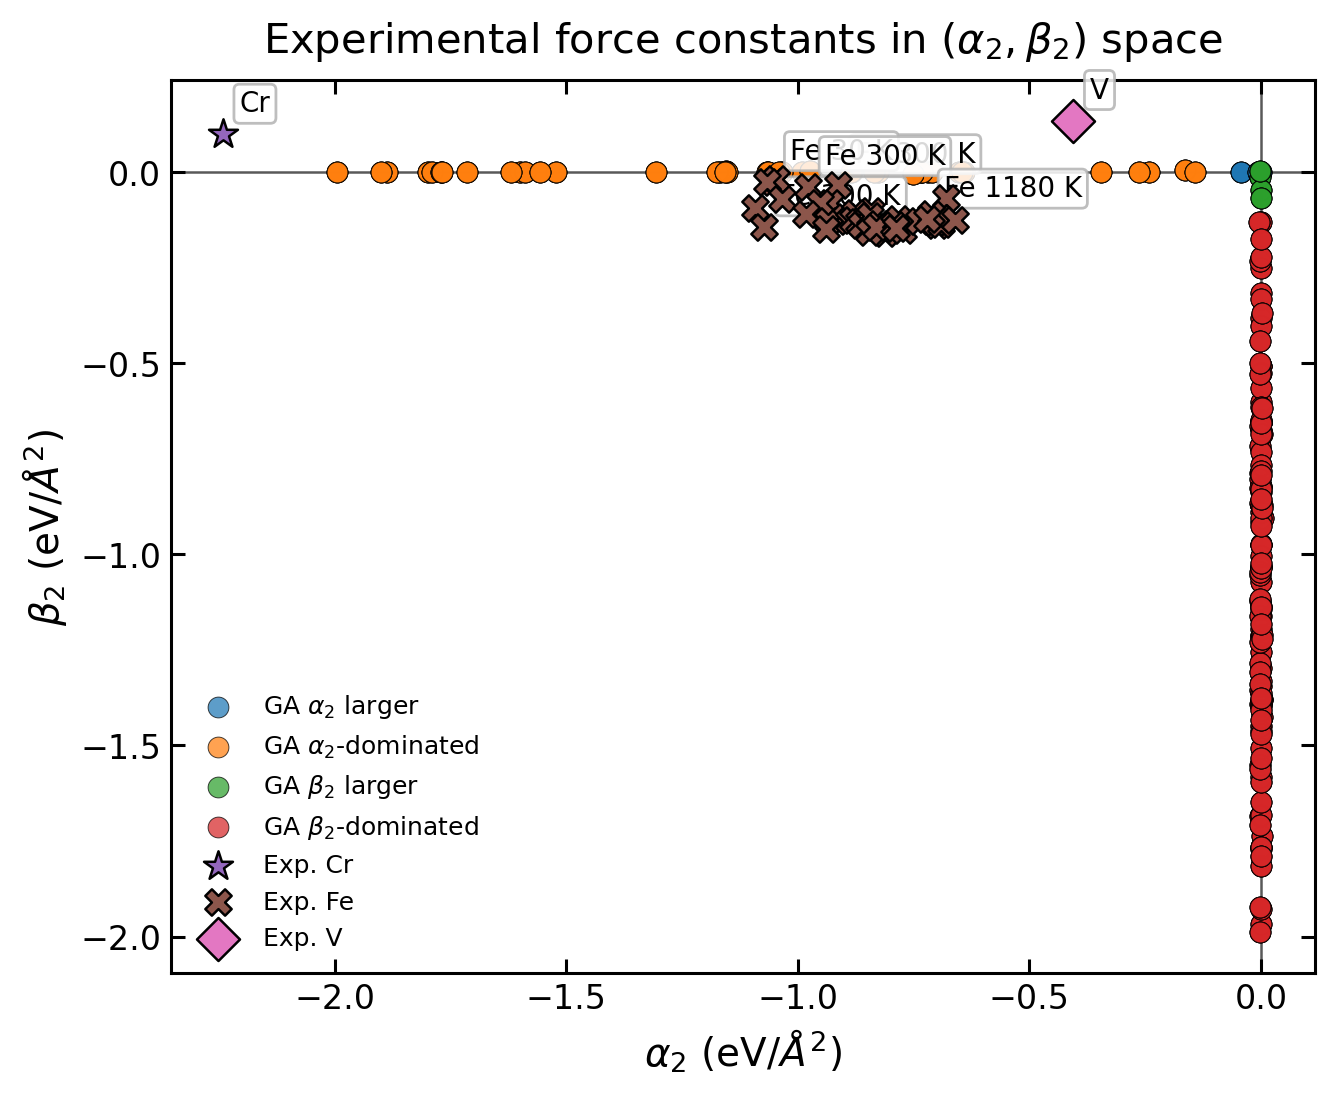

In [12]:
# -----------------------------------------------------------------------------
# Figure 3: alpha2-beta2 plane with experimental overlay
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=FIGSIZE)

for family, sub in df_ga.groupby("family"):
    ax.scatter(
        sub[alpha2_col],
        sub[beta2_col],
        s=MARKER_SIZE_GA,
        alpha=MARKER_ALPHA_GA,
        edgecolors="black",
        linewidths=EDGE_WIDTH,
        label=f"GA {family}",
    )

for element, sub in df_exp.groupby("element"):
    ax.scatter(
        sub["alpha2_eV_A2"],
        sub["beta2_eV_A2"],
        s=MARKER_SIZE_EXP if element != "Fe" else MARKER_SIZE_EXP * 0.75,
        marker=element_markers.get(element, "P"),
        edgecolors="black",
        linewidths=0.9,
        label=f"Exp. {element}",
        zorder=5,
    )

# Label only Cr, V, and selected Fe temperatures.
for _, row in df_exp.iterrows():
    label = None
    if row["element"] != "Fe":
        label = row["element"]
    elif row["temperature_K"] in [30, 300, 1180]:
        label = f"Fe {int(row['temperature_K'])} K"
    if label is not None:
        ax.annotate(
            label,
            xy=(row["alpha2_eV_A2"], row["beta2_eV_A2"]),
            xytext=(6, 6),
            textcoords="offset points",
            fontsize=10,
            ha="left",
            va="bottom",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="0.7", alpha=0.85),
        )

ax.axhline(0, color="0.35", linewidth=0.9, zorder=0)
ax.axvline(0, color="0.35", linewidth=0.9, zorder=0)

ax.set_xlabel(r"$\alpha_2$ (eV/$\AA^2$)", fontsize=14)
ax.set_ylabel(r"$\beta_2$ (eV/$\AA^2$)", fontsize=14)
ax.set_title(r"Experimental force constants in $(\alpha_2,\beta_2)$ space", fontsize=15, pad=10)

apply_publication_axes(ax)
ax.legend(frameon=False, fontsize=9, loc="best")

fig.tight_layout()
save_figure(fig, "alpha2_beta2_ga_with_experimental_overlay")
plt.show()


Saved:
  experimental_overlay_force_constant_space/fe_temperature_trajectory_in_pca_space.pdf
  experimental_overlay_force_constant_space/fe_temperature_trajectory_in_pca_space.png


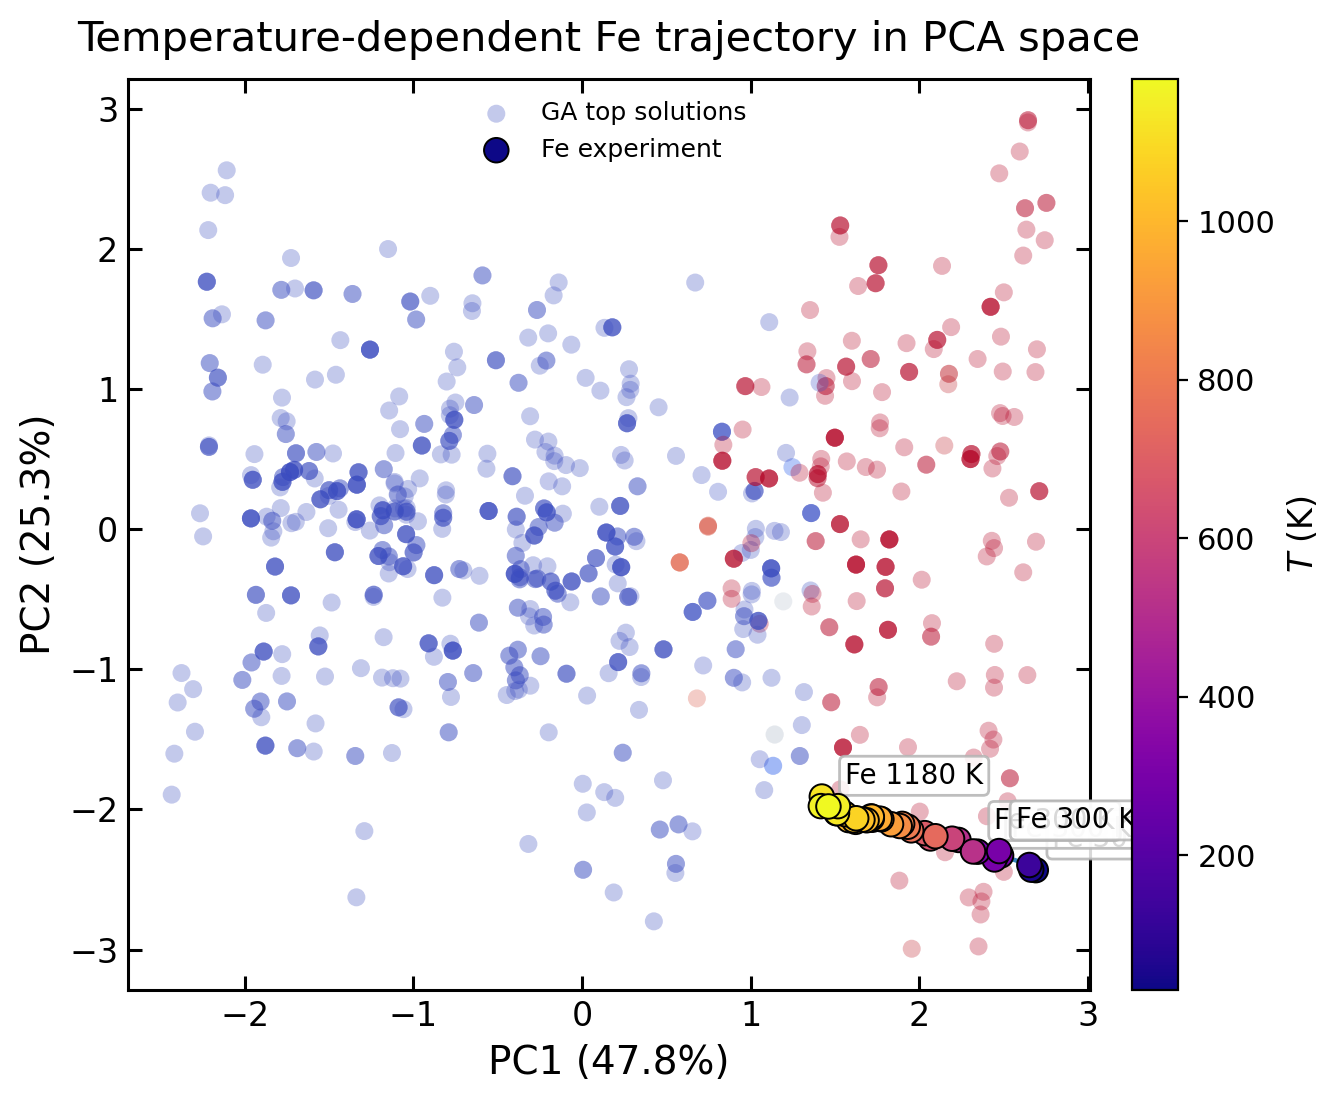

In [13]:
# -----------------------------------------------------------------------------
# Figure 4: Fe temperature trajectory in PCA space
# -----------------------------------------------------------------------------

df_fe = df_exp[df_exp["element"] == "Fe"].sort_values("temperature_K").copy()

fig, ax = plt.subplots(figsize=FIGSIZE)

# GA background colored by r_alpha2.
sc_bg = ax.scatter(
    df_ga["PC1"],
    df_ga["PC2"],
    c=df_ga["r_alpha2"],
    cmap="coolwarm",
    vmin=0,
    vmax=1,
    s=MARKER_SIZE_GA * 0.75,
    alpha=0.30,
    edgecolors="none",
    label="GA top solutions",
)

# Fe trajectory.
line = ax.plot(
    df_fe["PC1"],
    df_fe["PC2"],
    linewidth=1.6,
    alpha=0.9,
    zorder=5,
)[0]

sc_fe = ax.scatter(
    df_fe["PC1"],
    df_fe["PC2"],
    c=df_fe["temperature_K"],
    cmap="plasma",
    s=MARKER_SIZE_EXP * 0.65,
    edgecolors="black",
    linewidths=0.7,
    zorder=6,
    label="Fe experiment",
)

add_element_labels(ax, df_fe)

ax.set_xlabel(f"PC1 ({explained[0]*100:.1f}%)", fontsize=14)
ax.set_ylabel(f"PC2 ({explained[1]*100:.1f}%)", fontsize=14)
ax.set_title("Temperature-dependent Fe trajectory in PCA space", fontsize=15, pad=10)

apply_publication_axes(ax)

cbar = fig.colorbar(sc_fe, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label(r"$T$ (K)", fontsize=12)
cbar.ax.tick_params(labelsize=11)

ax.legend(frameon=False, fontsize=9, loc="best")

fig.tight_layout()
save_figure(fig, "fe_temperature_trajectory_in_pca_space")
plt.show()


Saved:
  experimental_overlay_force_constant_space/fe_temperature_trajectory_in_alpha2_beta2_space.pdf
  experimental_overlay_force_constant_space/fe_temperature_trajectory_in_alpha2_beta2_space.png


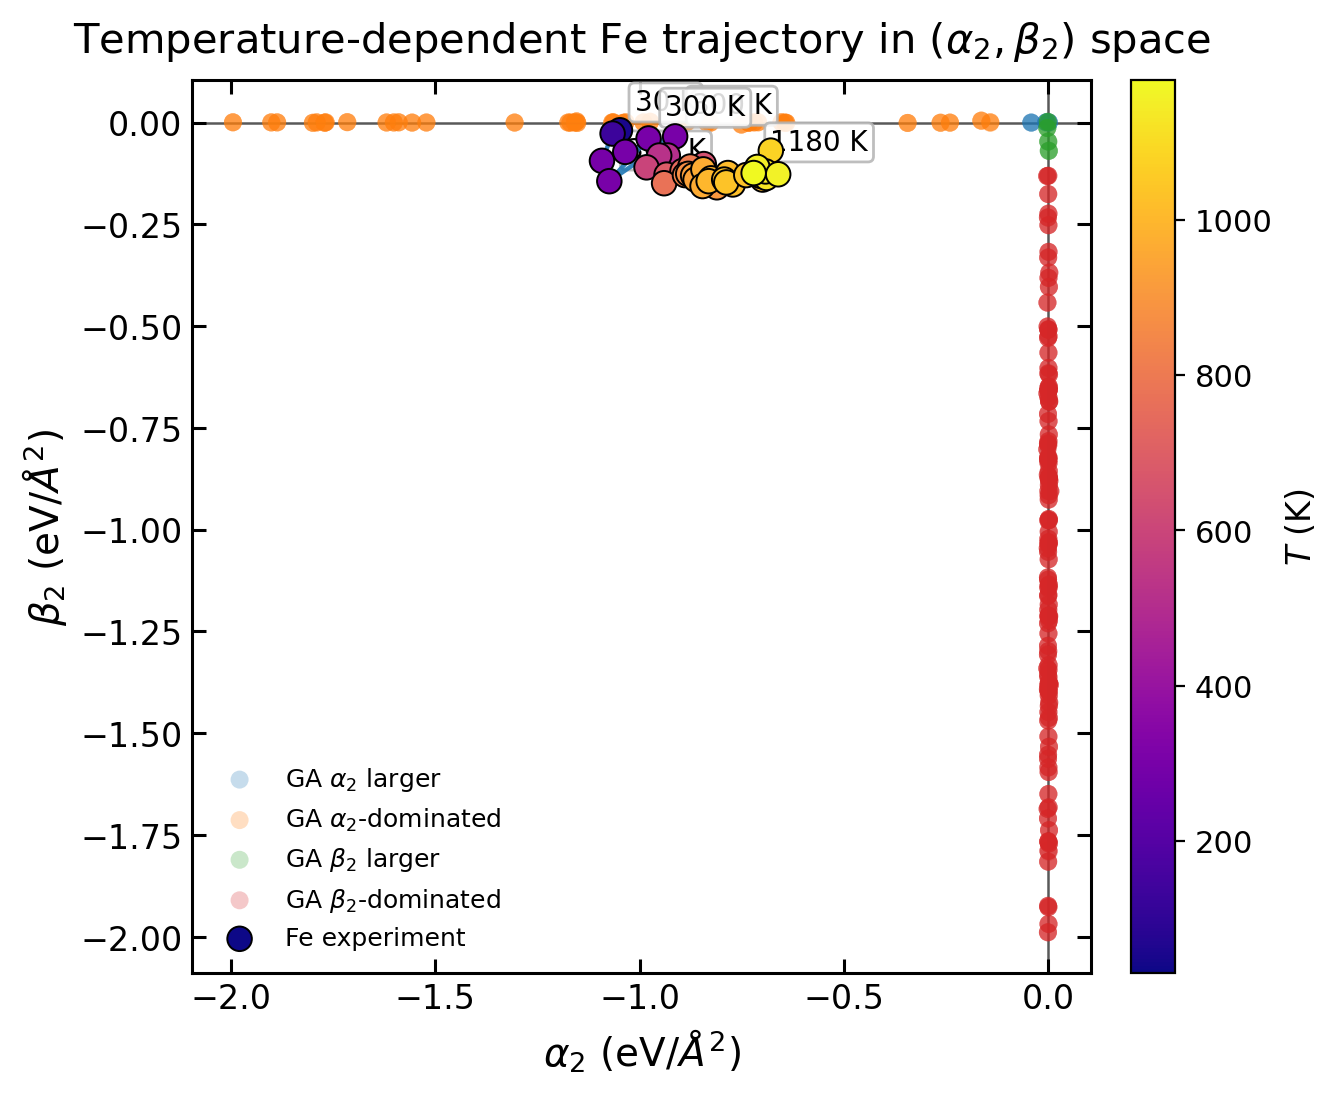

In [14]:
# -----------------------------------------------------------------------------
# Figure 5: Fe temperature trajectory in alpha2-beta2 space
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=FIGSIZE)

for family, sub in df_ga.groupby("family"):
    ax.scatter(
        sub[alpha2_col],
        sub[beta2_col],
        s=MARKER_SIZE_GA * 0.75,
        alpha=0.25,
        edgecolors="none",
        label=f"GA {family}",
    )

ax.plot(
    df_fe["alpha2_eV_A2"],
    df_fe["beta2_eV_A2"],
    linewidth=1.6,
    alpha=0.9,
    zorder=5,
)

sc_fe = ax.scatter(
    df_fe["alpha2_eV_A2"],
    df_fe["beta2_eV_A2"],
    c=df_fe["temperature_K"],
    cmap="plasma",
    s=MARKER_SIZE_EXP * 0.65,
    edgecolors="black",
    linewidths=0.7,
    zorder=6,
    label="Fe experiment",
)

for _, row in df_fe.iterrows():
    if row["temperature_K"] in [30, 300, 1180]:
        ax.annotate(
            f"{int(row['temperature_K'])} K",
            xy=(row["alpha2_eV_A2"], row["beta2_eV_A2"]),
            xytext=(6, 6),
            textcoords="offset points",
            fontsize=10,
            ha="left",
            va="bottom",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="0.7", alpha=0.85),
        )

ax.axhline(0, color="0.35", linewidth=0.9, zorder=0)
ax.axvline(0, color="0.35", linewidth=0.9, zorder=0)

ax.set_xlabel(r"$\alpha_2$ (eV/$\AA^2$)", fontsize=14)
ax.set_ylabel(r"$\beta_2$ (eV/$\AA^2$)", fontsize=14)
ax.set_title(r"Temperature-dependent Fe trajectory in $(\alpha_2,\beta_2)$ space", fontsize=15, pad=10)

apply_publication_axes(ax)

cbar = fig.colorbar(sc_fe, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label(r"$T$ (K)", fontsize=12)
cbar.ax.tick_params(labelsize=11)

ax.legend(frameon=False, fontsize=9, loc="best")

fig.tight_layout()
save_figure(fig, "fe_temperature_trajectory_in_alpha2_beta2_space")
plt.show()


In [15]:
# -----------------------------------------------------------------------------
# Save projected data and PCA loadings
# -----------------------------------------------------------------------------

ga_out = OUTPUT_DIR / "ga_top5_projected_pca_space.csv"
exp_out = OUTPUT_DIR / "experimental_projected_pca_space.csv"
loadings_out = OUTPUT_DIR / "pca_loadings_4d_alpha1_beta1_alpha2_beta2.csv"

df_ga.to_csv(ga_out, index=False)
df_exp.to_csv(exp_out, index=False)
loadings.to_csv(loadings_out)

print("Saved:")
print(f"  {ga_out}")
print(f"  {exp_out}")
print(f"  {loadings_out}")


Saved:
  experimental_overlay_force_constant_space/ga_top5_projected_pca_space.csv
  experimental_overlay_force_constant_space/experimental_projected_pca_space.csv
  experimental_overlay_force_constant_space/pca_loadings_4d_alpha1_beta1_alpha2_beta2.csv


## Interpretation guide

The PCA model is fit using the GA-discovered top-ranked force constants. The experimental Cr, V, and Fe points are then projected into that same PCA coordinate system. If the experimental points fall within or near the \(\alpha_2\)-dominated GA family, this supports the interpretation that the GA has discovered a physically relevant region of BCC force-constant space.

Because the experimental data contain only \((\alpha_1,\beta_1,\alpha_2,\beta_2)\), this notebook performs PCA in the corresponding four-dimensional subspace. This makes the comparison direct and avoids assumptions about the onsite parameter \(\alpha_0\), which is not reported in the experimental tables.
